In [98]:
# Eksplorasi E commerce churn

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import re
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, cross_validate

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
import category_encoders as ce
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, precision_score, fbeta_score, make_scorer, ConfusionMatrixDisplay, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# **1. BACKGROUND**

Industri Online E-Commerce merupakan salah satu sektor dengan tingkat persaingan paling intens, dalam industri yang kompetitif ini, berdasarkan Harvard Business Review, mempertahankan pelanggan existing jauh lebih hemat biaya dibandingkan mengakuisisi pelanggan baru. Biaya akuisisi pelanggan (Customer Acquisition Cost / CAC) yang tinggi membuat churn menjadi isu bisnis yang kritikal. Setiap pelanggan yang churn tidak hanya menyebabkan hilangnya pendapatan saat ini, tetapi juga potensi pendapatan jangka panjang.
(https://hbr.org/2014/10/the-value-of-keeping-the-right-customers).

Dataset ini mencakup perilaku pelanggan online e-commerce, mulai dari demografi, interaksi aplikasi (seperti HourSpendOnApp), hingga riwayat transaksi. Fokus utama perusahaan adalah memastikan pelanggan tetap aktif berbelanja di platform dan tidak berpindah ke kompetitor lain dimana perusahaan online e-commerce ini memilih untuk menekan pengeluaran yang tidak tepat sasaran. 

Fenomena Customer Churn, yaitu kondisi ketika pelanggan berhenti bertransaksi atau beralih ke kompetitor dalam periode tertentu, merupakan ancaman laten yang sering kali tidak terdeteksi sejak dini. Dalam konteks dataset E-Commerce yang digunakan pada proyek ini, churn tidak hanya mencerminkan penurunan aktivitas transaksi, tetapi juga kegagalan perusahaan dalam membangun pengalaman pelanggan yang berkelanjutan (sustainable customer experience).
Analisis awal terhadap data mengindikasikan bahwa loyalitas pelanggan tidak semata-mata ditentukan oleh faktor harga. Sebaliknya, churn dipengaruhi oleh kombinasi beberapa faktor seperti:

- Masa Langganan (Tenure): Tenure pendek bisa menunjukkan kecenderungan pelanggan baru cenderung lebih rentan untuk churn dibandingkan pelanggan lama yang sudah memiliki trust.
- Faktor Keluhan (Complain): Pelanggan yang menyampaikan keluhan memiliki risiko churn yang jauh lebih tinggi jika tidak ditangani dengan strategi recovery yang cepat.
- Insentif vs Loyalitas: Perusahaan mengeluarkan biaya besar untuk cashback, namun perlu dievaluasi apakah pemberian subsidi ini benar-benar efektif menahan pelanggan atau justru membebani margin perusahaan.
- Keadaan Logistik: Jarak antara gudang ke rumah pelanggan `WarehouseToHome` menjadi variabel krusial yang mempengaruhi kecepatan pengiriman dan kepuasan pelanggan.

Kegagalan dalam memprediksi churn secara dini menyebabkan tim marketing terus melakukan promosi "buta" kepada semua orang, yang mengakibatkan inefisiensi anggaran dan rendahnya Return on Investment (ROI) dari program retensi.



# **2. PROBLEM STATEMENT**

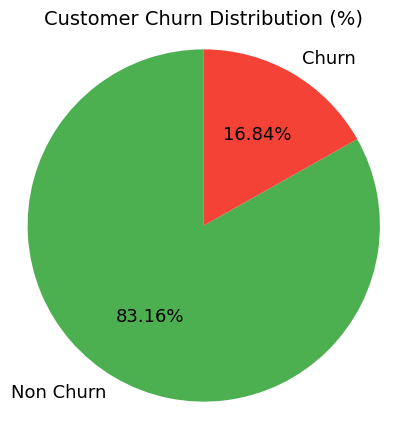


Berdasarkan (https://kiriminaja.com/blog/tingkat-customer-churn-sehat), churn rate adalah persentase pelanggan yang berhenti beli dalam periode tertentu. Kondisi churn rate yang sehat berada pada kisaran angka 5-8% sedangkan churn rate pada dataset ini ada di angka 16.84% sehingga nilai churn rate pada dataset ini dinilai tidak sehat. 

`Masalah: Kondisi Churn Rate yang melebihi ambang batas normal retail online e-commerce.`

**Risiko Bisnis:** `Jika perusahaan memberikan promo ke semua orang tanpa target, akan terjadi pemborosan biaya pemasaran. Sebaliknya, jika perusahaan gagal mendeteksi pelanggan yang akan pergi, pangsa pasar akan menurun.`



# **3. GOALS**

`Goals Utama: Membangun sistem prediksi churn yang akurat untuk mengidentifikasi pelanggan churn dan faktor-faktor yang mempengaruhi fenomena churn untuk meminimalisir pelanggan churn.`

Pencapaian yang diperlukan:
1.	**Profiling Pelanggan High Risk (Churn):** Memetakan karakteristik demografi dan perilaku (seperti kategori produk favorit, jarak rumah, dan jumlah perangkat) yang menjadi indikator kuat churn.
2.	**Mengidentifikasi variabel-variabel kunci yang berkontribusi terhadap churn pelanggan:** Optimalisasi dalam alokasi pengeluaran yang berdampak besar selain pemberian cashback. 
3.	**Service Recovery Strategy:** Menyusun rekomendasi untuk tim operasional mengenai penanganan pelanggan yang melakukan Complain berdasarkan tingkat risiko churn mereka.

# **4. ANALYTICAL APPROACH**

Pendekatan analitik dilakukan secara sistematis dengan fokus pada efisiensi pengolahan data tanpa mengurangi akurasi prediksi:

Pertama, Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik churn. Kami menganalisis distribusi variabel kunci seperti Tenure dan Complain untuk menemukan tipping point di mana pelanggan mulai menunjukkan tanda-tanda ketidakpuasan. Kami juga mengevaluasi hubungan antara jarak logistik (WarehouseToHome) dengan frekuensi komplain untuk memetakan risiko operasional.

Kedua, Manual Data Imputation & Cleaning. Alih-alih menggunakan algoritma stokastik, kami menerapkan imputasi manual yang berbasis konteks data:
- Tenure: Nilai kosong dan NaN diisi dengan Median berdasarkan kelompok `CityTier`, karena lama berlangganan seringkali memiliki pola serupa dalam tingkatan ekonomi kota yang sama.
- `WarehouseToHome`: Pengisian NaN Menggunakan Median global untuk menghindari pengaruh pencilan (outliers) yang ekstrim.
- `DaySinceLastOrder`: Mengisi nilai kosong dengan 0. Kosong karena ada kemungkinan pelanggan tersebut memang belum pernah melakukan pemesanan ulang setelah transaksi pertama.
- Inconsistency Handling: Melakukan penyeragaman label pada kategori yang tumpang tindih seperti mengubah 'CC' menjadi 'Credit Card' dan 'Mobile Phone' menjadi 'Mobile'.

Ketiga, Feature Engineering (Strategic Features). Kami menciptakan fitur baru yang memiliki daya pembeda tinggi bagi model:
* Angry Customer Flag: Menggabungkan pelanggan yang memiliki `Complain aktif == 1` dan `SatisfactionScore` rendah (≤ 2).
* Cashback Efficiency: Rasio `CashbackAmount` terhadap `OrderCount` untuk mendeteksi pelanggan yang hanya aktif saat ada subsidi besar.
* App Intensity: Interaksi antara `HourSpendOnApp` dengan `NumberOfDeviceRegistered` untuk mengukur tingkat keterikatan pelanggan terhadap ekosistem platform.
* Engagement: `HourSpendOnApp`, `OrderCount`, `DaySinceLastOrder`

* Distance vs Delivery Risk: Mengkategorikan WarehouseToHome menjadi:
    - Near (<10 km)
    - Medium (10-25 km)
    - Far (>25 km) Logistik yang jauh sering menjadi alasan utama komplain dan churn.

Keempat, Pemodelan Prediktif. Kami menggunakan algoritma ensemble tingkat lanjut yaitu XGBoost dan Random Forest. 
Untuk menangani ketidakseimbangan data (di mana kelas churn jauh lebih sedikit), kami menggunakan teknik SMOTE di dalam Pipeline sebelum tahap pelatihan model.

# **5. METRICS EVALUATION**

Dalam klasifikasi churn, nilai akurasi sering kali membingungkan. Kami menggunakan pendekatan Cost-Benefit Analysis melalui Confusion Matrix untuk menentukan metrik terbaik bagi profitabilitas perusahaan.

Untuk memahaminya secara mendalam, kita menggunakan Confusion Matrix sebagai dasar perhitungan. Dalam kasus ini, kita mendefinisikan:

- Positif (1): Pelanggan yang Churn (Berhenti belanja/meninggalkan platform).

- negatif (0): Pelanggan yang Non Churn (Tetap setia/aktif belanja).

Confusion Matrix membagi hasil prediksi model menjadi empat komponen utama:

| Komponen                | Definisi                         | Dampak Bisnis                                                                                         | Biaya                             |
| ----------------------- | -------------------------------- | ----------------------------------------------------------------------------------------------------- | --------------------------------- |
| **True Positive (TP)**  | Prediksi *Churn*, Aktual *Churn* | **Sukses**: Intervensi retensi dilakukan tepat waktu sehingga pelanggan berhasil dipertahankan        | Biaya Promo (Kecil)               |
| **True Negative (TN)**  | Prediksi *Stay*, Aktual *Stay*   | **Efisiensi**: Tidak mengalokasikan promo pada pelanggan yang memang loyal                            | Rp 0                              |
| **False Positive (FP)** | Prediksi *Churn*, Aktual *Stay*  | **Inefisiensi**: Diskon atau insentif diberikan kepada pelanggan yang sebenarnya tidak berisiko churn | Biaya Promo (Marginal)            |
| **False Negative (FN)** | Prediksi *Stay*, Aktual *Churn*  | **Kegagalan**: Pelanggan bernilai tinggi hilang tanpa sempat dilakukan pencegahan                     | Lost Revenue + CAC (Sangat Besar) |

Dampak paling besar: False Negative (FN)

Oleh karena itu, 
**(Metrik Utama) = Recall** Karena prioritas kami adalah meminimalkan False Negative.

`“Lebih baik memberikan voucher kepada 10 orang setia (FP) daripada kehilangan 1 pelanggan berharga selamanya (FN).” Recall yang tinggi memastikan sistem Early Warning kita menangkap sebanyak mungkin calon churner.`

## **DATA UNDERSTANDING**

**Dataset source:** 

https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

**Data Information:**

| Variable                    | Description                       | Business Relevance to Churn                                     |
| --------------------------- | --------------------------------- | --------------------------------------------------------------- |
| CustomerID                  | Unique customer identifier        | Identifier unik, **tidak digunakan sebagai fitur model**        |
| Churn                       | Churn flag                        | **Target variable** (1 = churn, 0 = tidak churn)                |
| Tenure                      | Lama pelanggan bergabung (bulan)  | Pelanggan baru biasanya **lebih rentan churn**                  |
| PreferredLoginDevice        | Perangkat login utama             | UX pada device tertentu dapat memengaruhi churn                 |
| CityTier                    | Tingkatan kota                    | Akses logistik & kualitas layanan memengaruhi loyalitas         |
| WarehouseToHome             | Jarak gudang ke rumah             | Jarak jauh → pengiriman lebih lama → **risiko churn meningkat** |
| PreferredPaymentMode        | Metode pembayaran favorit         | Metode terbatas dapat menurunkan kenyamanan                     |
| Gender                      | Gender pelanggan                  | Faktor demografis pendukung                                     |
| HourSpendOnApp              | Jam penggunaan aplikasi/web       | Engagement rendah = **indikasi churn**                          |
| NumberOfDeviceRegistered    | Jumlah device terdaftar           | Multi-device menandakan engagement lebih tinggi                 |
| PreferedOrderCat            | Kategori pesanan favorit          | Preferensi produk memengaruhi retensi                           |
| SatisfactionScore           | Skor kepuasan layanan             | **Salah satu indikator churn terkuat**                          |
| MaritalStatus               | Status pernikahan                 | Faktor demografis pendukung                                     |
| NumberOfAddress             | Jumlah alamat tersimpan           | Lebih banyak alamat = **pelanggan lebih loyal**                 |
| Complain                    | Keluhan dalam 1 bulan terakhir    | Keluhan → **risiko churn tinggi**                               |
| OrderAmountHikeFromlastYear | Kenaikan nilai order (%)          | Membedakan pelanggan bertumbuh vs stagnan                       |
| CouponUsed                  | Jumlah kupon digunakan            | Menggambarkan sensitivitas terhadap promo                       |
| OrderCount                  | Jumlah order bulan terakhir       | Tingkat aktivitas transaksi                                     |
| DaySinceLastOrder           | Hari sejak order terakhir         | Recency tinggi = **churn risk meningkat**                       |
| CashbackAmount              | Rata-rata cashback bulan terakhir | Mengukur efektivitas insentif                                   |


In [2]:
df = pd.read_excel("ecommerce_churn.xlsx")
df.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [119]:
df.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

## **GENERAL INFORMATION**

In [3]:
# Analisis Deskriptif

display(df.head())
display(df.info())

# Proporsi Pelanggan Churn

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

None

Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


In [4]:
df['CityTier'] = df['CityTier'].astype('category')
df['Churn'] = df['Churn'].astype('category')
df['Complain'] = df['Complain'].astype('category')


display(df.describe(include=['category', 'object']).T)

,count,unique,top,freq
Churn,5630,2,0,4682
PreferredLoginDevice,5630,3,Mobile Phone,2765
CityTier,5630,3,1,3666
PreferredPaymentMode,5630,7,Debit Card,2314
Gender,5630,2,Male,3384
PreferedOrderCat,5630,6,Laptop & Accessory,2050
MaritalStatus,5630,3,Married,2986
Complain,5630,2,0,4026


In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
OrderAmountHikeFromlastYear,5365.0,15.707922,3.675485,11.0,13.00,15.00,18.0000,26.00
CouponUsed,5374.0,1.751023,1.894621,0.0,1.00,1.00,2.0000,16.00
OrderCount,5372.0,3.008004,2.939680,1.0,1.00,2.00,3.0000,16.00


# **ANALISIS DESKRIPTIF**

## Gambaran Umum Dataset & Prediksi Probabilitas

Dataset ini terdiri dari **5.630 pelanggan**, di mana setiap baris merepresentasikan satu pelanggan e-commerce. 
Dataset mencakup informasi demografis, perilaku penggunaan aplikasi, aktivitas transaksi, kepuasan pelanggan, logistik, serta status **Customer Churn** sebesar 16,8%

**Analisis Kolom**
1. Tenure (Masa Berlangganan)
- Rata-rata: **10,19 bulan**
- Minimum: **0 bulan**
- Maksimum: **61 bulan**

Mayoritas pelanggan masih berada pada fase awal–menengah siklus hidup. Pelanggan dengan **tenure rendah** berpotensi lebih rentan terhadap churn karena loyalitas belum terbentuk.

2. WarehouseToHome (Jarak Gudang ke Rumah)
- Rata-rata: **15,64 km**
- Minimum: **5 km**
- Maksimum: **127 km**

Variasi jarak yang besar menunjukkan potensi perbedaan kualitas layanan logistik. Jarak yang jauh berpotensi meningkatkan keterlambatan pengiriman dan risiko churn.

3. HourSpendOnApp (Waktu Penggunaan Aplikasi)
- Rata-rata: **2,93 jam/hari**
- Minimum: **0 jam**
- Maksimum: **5 jam**

Durasi penggunaan mencerminkan engagement pelanggan. Penurunan waktu penggunaan dapat menjadi sinyal awal churn.

4. NumberOfDeviceRegistered
- Rata-rata: **3,69 perangkat**
- Rentang: **1-6 perangkat**

Jumlah perangkat yang lebih banyak mengindikasikan keterikatan (engagement) yang lebih tinggi terhadap platform.

5. SatisfactionScore (Skor Kepuasan)
- Skala: **1-5**
- Rata-rata: **3,07**
- Minimum: **1**

Skor kepuasan berada pada tingkat sedang. Pelanggan dengan skor rendah berpotensi memiliki risiko churn lebih tinggi, terutama jika disertai keluhan.

- Selain itu, mayoritas pelanggan berasal dari `CityTier` 1 dan 2 (rata-rata 1,65), menunjukkan dominasi wilayah metropolitan dan kota berkembang yang berpotensi memengaruhi churn melalui perbedaan daya beli, ekspektasi layanan, dan kualitas logistik mengalahkan CityTier 3. Mobile Phone menjadi perangkat login utama, menegaskan pentingnya optimalisasi UX aplikasi mobile untuk memudahkan penggunaan. Metode pembayaran paling umum adalah Debit Card, yang berperan dalam kenyamanan transaksi. Sekitar 28% pelanggan pernah melakukan complain, menjadikannya indikator kuat risiko churn jika tidak ditangani dengan baik. Beberapa variabel penting seperti **Tenure, WarehouseToHome, HourSpendOnApp, dan DaySinceLastOrder** memiliki missing value dalam proporsi kecil, sehingga imputation median lebih tepat dibandingkan penghapusan data untuk menjaga kualitas analisis dan pemodelan.

**Note: median digunakan untuk imputasi karena nilai mean dan median rata-rata sangat dekat dan lebih baik jika fitur-fitur memiliki value yang berupa integer. 


## **Data Cleaning**

In [6]:
# Periksa Missing Value
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [7]:
# Handle Missing Value 
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        
# Periksa Ulang Missing Value
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [8]:
# Cek Duplikasi Data
df.duplicated().sum()

np.int64(0)

**Explanation:** Tidak ada duplikasi nilai pada data.

In [9]:
df.drop(['CustomerID'],axis=1, inplace=True)

**Explanation:** Kolom tidak diperlukan. 

In [10]:
# Cek Duplikasi Kolom
cat_columns = df.select_dtypes(include=['object']).columns

for col in cat_columns:
    print(f"- Kolom: {col} -")
    print(f"Jumlah Unique: {df[col].nunique()}")
    print(f"Nilai: {df[col].unique()}")
    print("\n")

- Kolom: PreferredLoginDevice -
Jumlah Unique: 3
Nilai: ['Mobile Phone' 'Phone' 'Computer']


- Kolom: PreferredPaymentMode -
Jumlah Unique: 7
Nilai: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']


- Kolom: Gender -
Jumlah Unique: 2
Nilai: ['Female' 'Male']


- Kolom: PreferedOrderCat -
Jumlah Unique: 6
Nilai: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


- Kolom: MaritalStatus -
Jumlah Unique: 3
Nilai: ['Single' 'Divorced' 'Married']




# **Exploration Data Analysis & Data Visualization**

### **Univariate Analysis - Kategorikal**

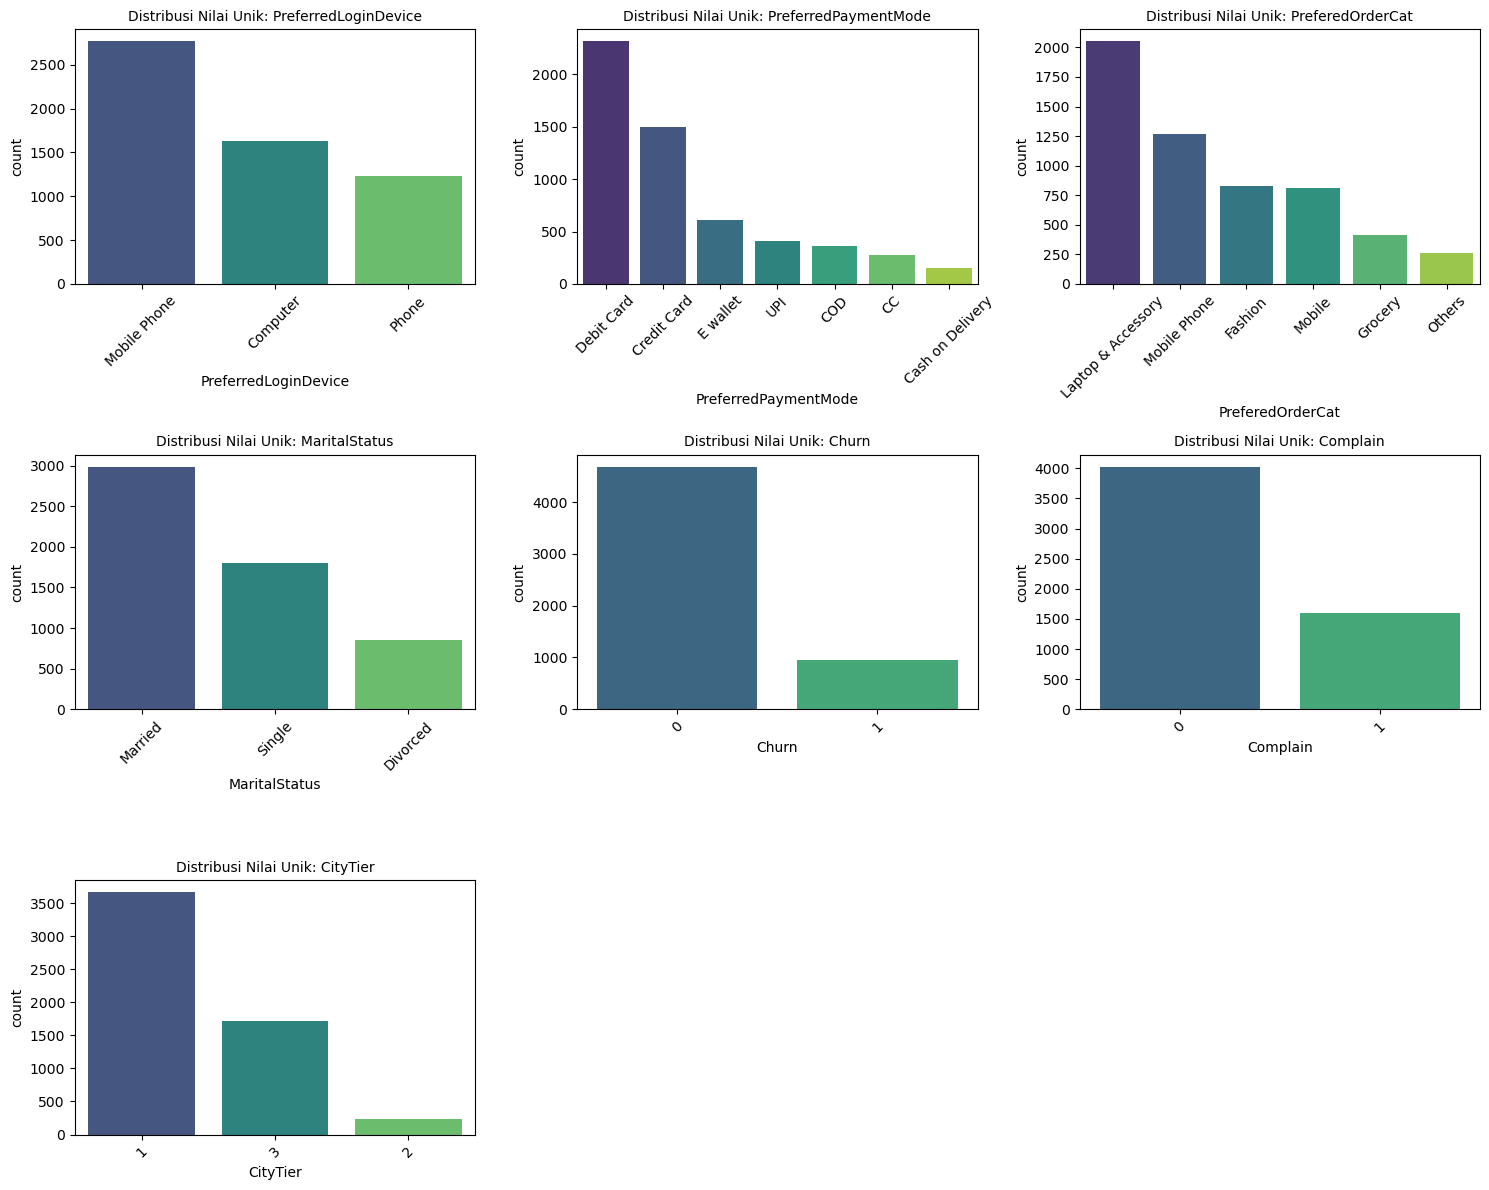

In [11]:
# Visualisasi unique values untuk 4 kolom kategori utama

cat_plot = [
    'PreferredLoginDevice', 'PreferredPaymentMode',
    'PreferedOrderCat', 'MaritalStatus',
    'Churn', 'Complain', 'CityTier'
]

n_cols = 3
n_rows = int(np.ceil(len(cat_plot) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cat_plot, 1):
    plt.subplot(n_rows, n_cols, i)

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='viridis')

    plt.title(f'Distribusi Nilai Unik: {col}', fontsize=10)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Explanation:** Pada dataset ini ditemukan inkonsistensi penamaan kategori yang dapat menimbulkan noise pada analisis dan pemodelan. Selanjutnya akan diatasi pada kolom `PreferredLoginDevice`, kategori Phone digabungkan ke dalam Mobile Phone karena memiliki makna yang sama. Tambahan, pada `PreferredPaymentMode`, beberapa singkatan seperti CC dan COD diseragamkan menjadi Credit Card dan Cash on Delivery agar preferensi metode pembayaran dapat dianalisis secara lebih akurat. Selain itu, pada `PreferedOrderCat`, kategori Mobile disatukan dengan Mobile Phone untuk menghindari duplikasi kategori produk. Proses ini bertujuan untuk meningkatkan konsistensi data, mengurangi jumlah kategori yang tidak perlu, serta memastikan kualitas fitur sebelum tahap encoding dan pemodelan machine learning.

In [12]:
# Mapping Data 

# 1. Merapikan PreferredLoginDevice
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')

# 2. Merapikan PreferredPaymentMode
# Menyatukan singkatan ke nama lengkap atau sebaliknya agar konsisten
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery',
})

# 3. Merapikan PreferedOrderCat
# Terkadang ada typo atau kategori yang sangat mirip (cek unique Anda)
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

# Cek hasil setelah re-mapping
for col in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(f"Unique {col}: {df[col].unique()}")


Unique PreferredLoginDevice: ['Mobile Phone' 'Computer']
Unique PreferredPaymentMode: ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
Unique PreferedOrderCat: ['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


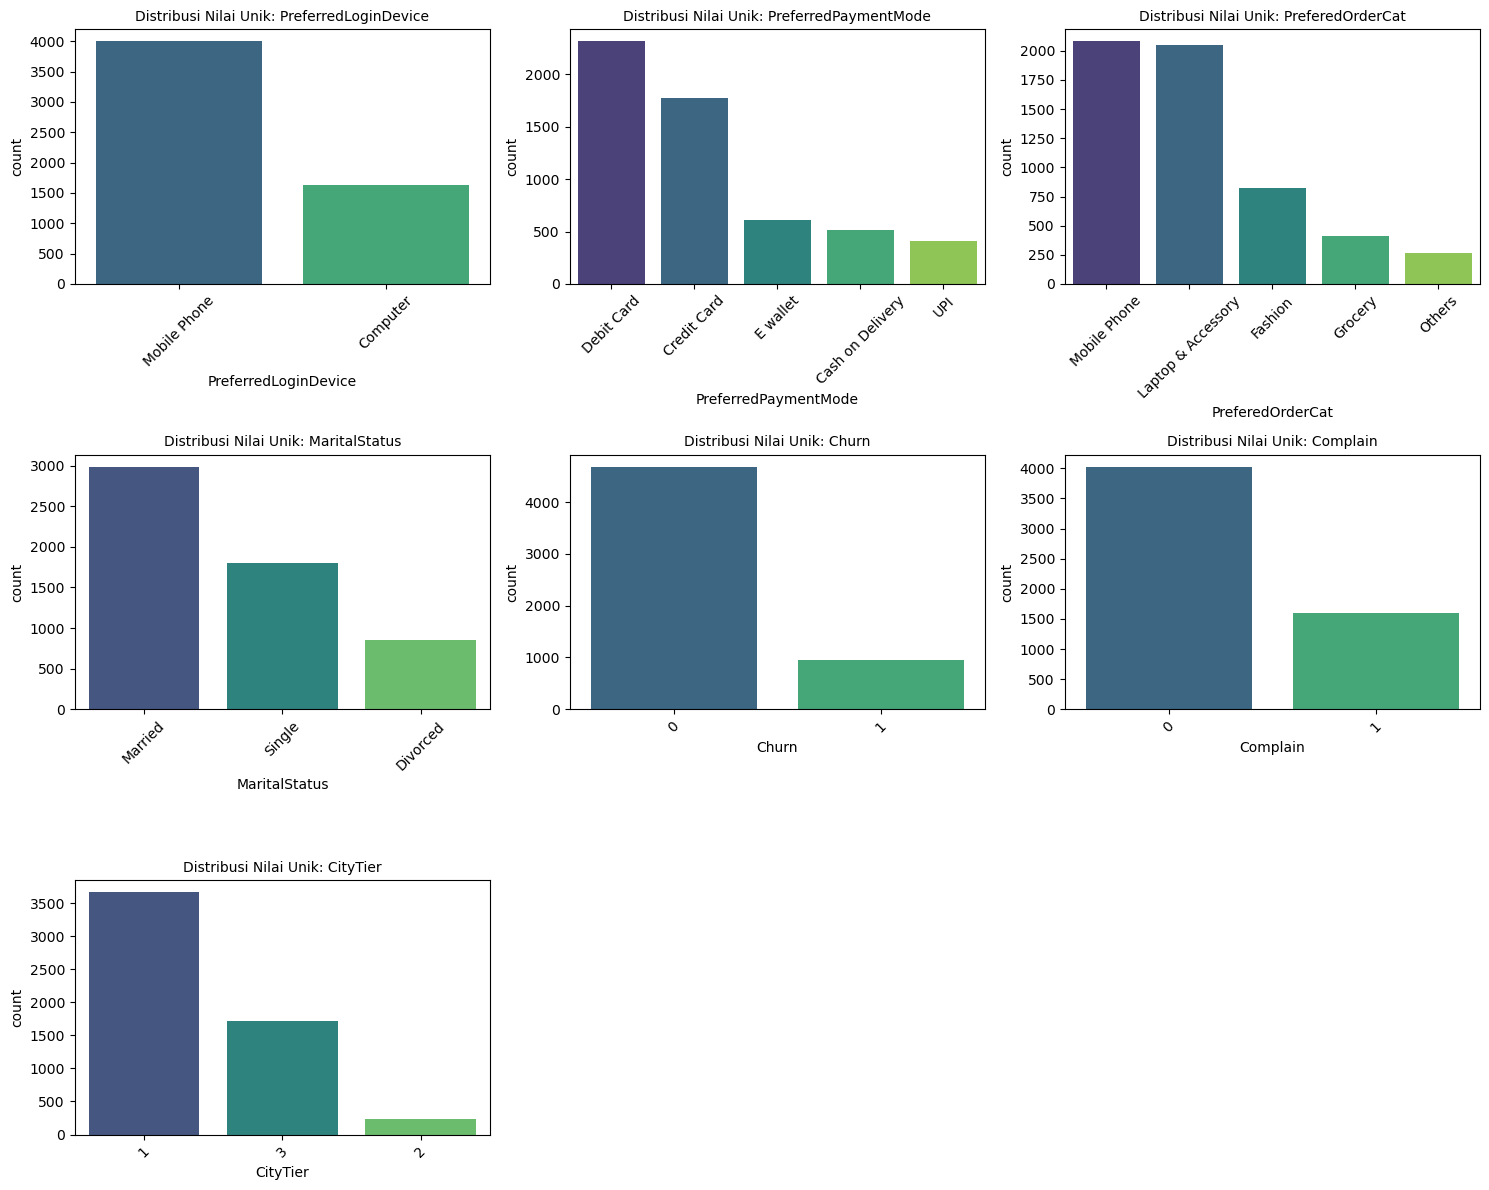

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(cat_plot) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cat_plot, 1):
    plt.subplot(n_rows, n_cols, i)

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='viridis')

    plt.title(f'Distribusi Nilai Unik: {col}', fontsize=10)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Explanation:** Setelah diperbaiki, nilai-nilai tiap kategori juga berubah. 

### **Univariate Analysis - Numerikal**

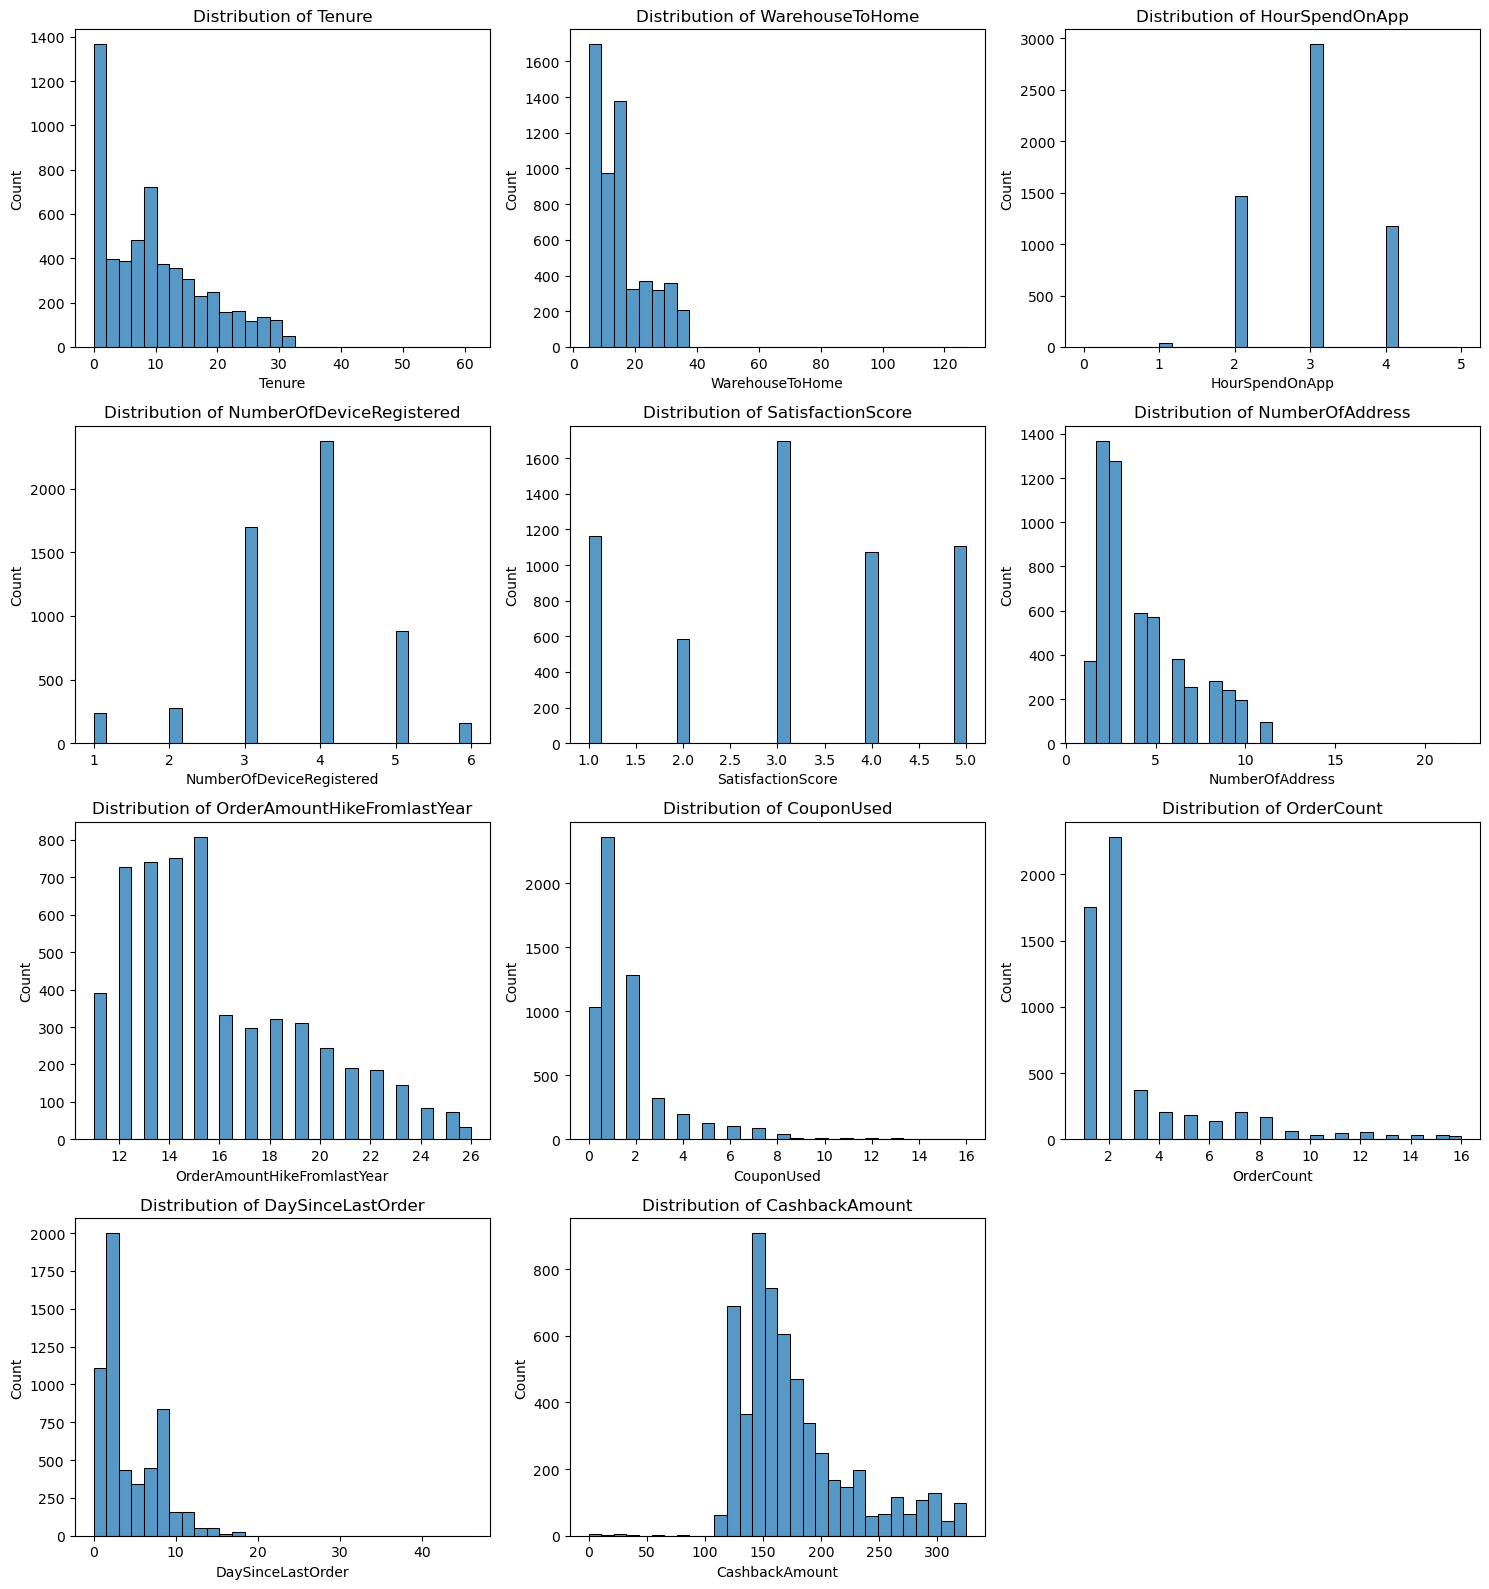

In [14]:
# Univariate Analysis

num_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = 3  
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import shapiro

num_cols = df.select_dtypes(include='number').columns

results = []

for col in num_cols:
    stat, p = shapiro(df[col].dropna())
    results.append({
        'Column': col,
        'p_value': p,
        'Normal': p > 0.05
    })

normality_df = pd.DataFrame(results)
normality_df

,Column,p_value,Normal
0,Tenure,5.520309e-47,False
1,WarehouseToHome,1.931021e-57,False
2,HourSpendOnApp,9.426686e-62,False
3,NumberOfDeviceRegistered,7.767200e-52,False
4,SatisfactionScore,1.186692e-53,False
5,NumberOfAddress,4.609121e-55,False
6,OrderAmountHikeFromlastYear,2.024211e-48,False
7,CouponUsed,5.399640e-71,False
8,OrderCount,2.284921e-74,False
9,DaySinceLastOrder,1.024041e-52,False


Dari visualisasi dan uji normalitas variabel numerik, dapat disimpulkan bahwa semua variabel numerik merupakan variabel non-parametrik (tidak berdistribusi normal). Oleh karena itu, central tendency yang kita gunakan untuk data tersebut adalah median.

**Explanation:** Sekitar 16.8% pelanggan mengalami churn, sementara 83.2% tetap aktif, yang mengindikasikan class imbalance. Kondisi ini penting karena model klasifikasi berpotensi bias ke kelas mayoritas, sehingga metrik seperti Recall lebih relevan.

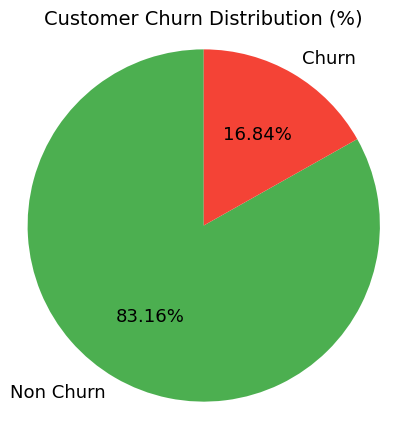

In [16]:
# Distribusi Persentase Customer Churn
churn = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(5, 5))
plt.pie(
    churn,
    labels=['Non Churn', 'Churn'],
    autopct='%.2f%%',
    startangle=90,
    textprops={'fontsize': 13},
    colors=['#4CAF50', '#F44336']
)
plt.title('Customer Churn Distribution (%)', fontsize=14)
plt.axis('equal')  # memastikan pie berbentuk lingkaran
plt.show()

**Explanation:** 

- Tenure condong ke kanan menunjukkan banyak pelanggan masih relatif baru
- CashbackAmount memiliki variasi besar memberi gambaran potensi overspending promosi
- DaySinceLastOrder memiliki `long-tail` atau ekor panjang → sinyal pelanggan tidak aktif

## Bivariate Analysis - Numerik


### Tenure vs Churn

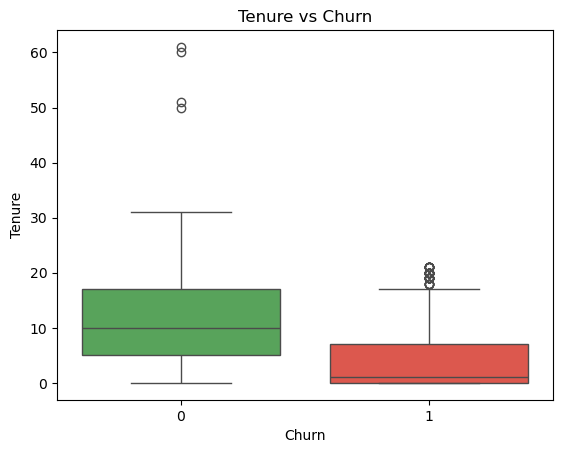

Churn
0    10.0
1     1.0
Name: Tenure, dtype: float64

In [17]:
sns.boxplot(x='Churn', y='Tenure', data=df, palette=['#4CAF50', '#F44336'])
plt.title("Tenure vs Churn")
plt.show()

df.groupby('Churn')['Tenure'].median()

In [18]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['Tenure'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 1414.4373873488094
p-value: 8.995944876516919e-275


**Explanation:** Tenure memiliki hubungan yang sangat signifikan dengan churn pelanggan.

### WarehouseToHome vs Churn

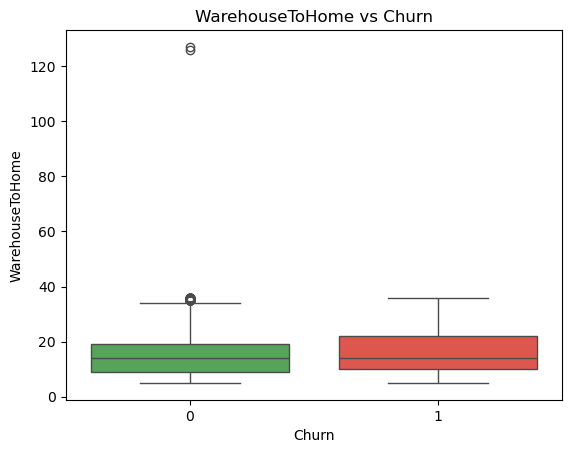

Churn
0    14.0
1    14.0
Name: WarehouseToHome, dtype: float64

In [19]:
sns.boxplot(x='Churn', y='WarehouseToHome', data=df, palette=['#4CAF50', '#F44336'])
plt.title("WarehouseToHome vs Churn")
plt.show()

df.groupby('Churn')['WarehouseToHome'].median()

In [20]:
ct = pd.crosstab(df['WarehouseToHome'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 95.56195633289906
p-value: 5.3293137859654506e-08


**Explanation:** Terdapat hubungan yang signifikan antara WarehouseToHome dan churn pelanggan

### HourSpendOnApp vs Churn

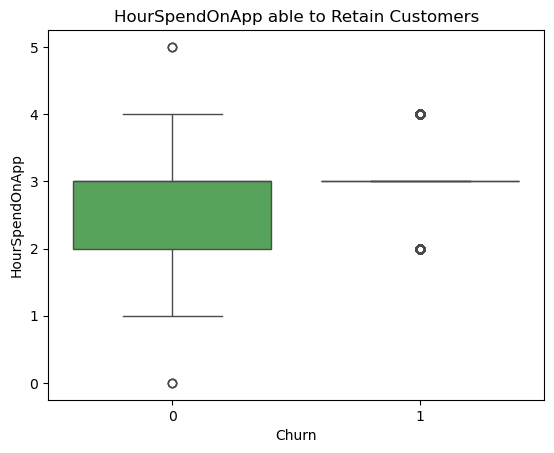

Churn
0    3.0
1    3.0
Name: HourSpendOnApp, dtype: float64

In [21]:
sns.boxplot(x='Churn', y='HourSpendOnApp', data=df, palette=['#4CAF50', '#F44336'])
plt.title("HourSpendOnApp able to Retain Customers")
plt.show()

df.groupby('Churn')['HourSpendOnApp'].median()

In [22]:
ct = pd.crosstab(df['HourSpendOnApp'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 10.73853464775109
p-value: 0.056817722186675745


**Explaination:** Tidak terdapat hubungan yang signifikan antara HourSpendOnApp dan Churn

### NumberOfDeviceRegistered vs Churn

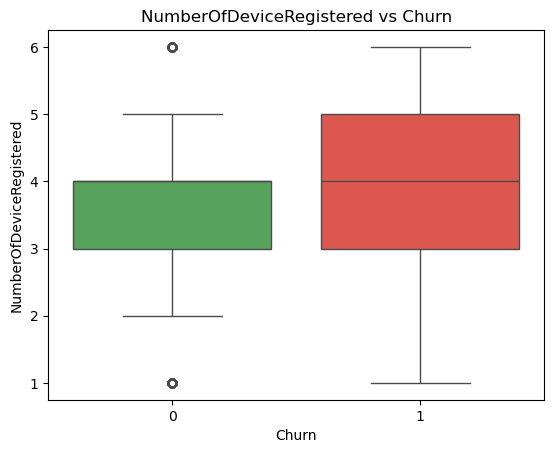

Churn
0    4.0
1    4.0
Name: NumberOfDeviceRegistered, dtype: float64

In [23]:
sns.boxplot(x='Churn', y='NumberOfDeviceRegistered', data=df, palette=['#4CAF50', '#F44336'])
plt.title("NumberOfDeviceRegistered vs Churn")
plt.show()

df.groupby('Churn')['NumberOfDeviceRegistered'].median()

In [24]:
ct = pd.crosstab(df['NumberOfDeviceRegistered'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 81.10881492998416
p-value: 4.918442967906057e-16


**Explaination:** Terdapat hubungan yang signifikan antara NumberOfDeviceRegistered dan Churn

### SatisfactionScore vs Churn

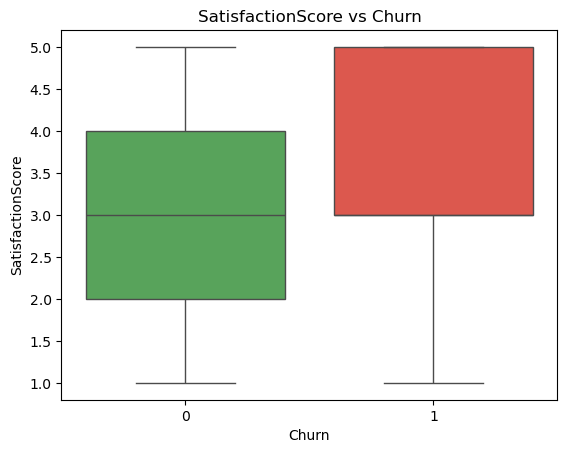

Churn
0    3.0
1    3.0
Name: SatisfactionScore, dtype: float64

In [25]:
sns.boxplot(x='Churn', y='SatisfactionScore', data=df, palette=['#4CAF50', '#F44336'])
plt.title("SatisfactionScore vs Churn")
plt.show()

df.groupby('Churn')['SatisfactionScore'].median()

In [26]:
ct = pd.crosstab(df['SatisfactionScore'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 69.8653884066938
p-value: 2.4233349782737515e-14


**Explaination:** Terdapat hubungan yang signifikan antara SatisfactionScore dan Churn

### NumberOfAddress vs Churn

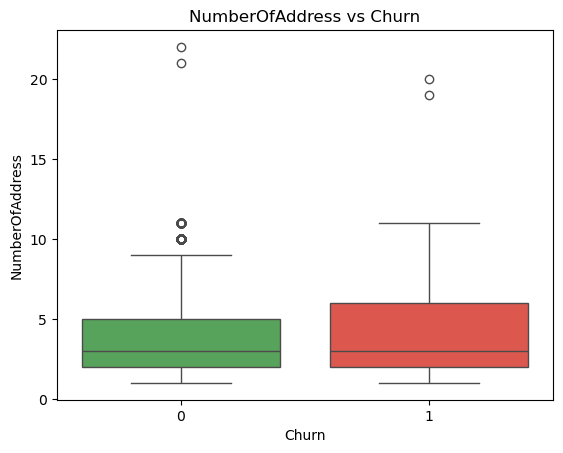

Churn
0    3.0
1    3.0
Name: NumberOfAddress, dtype: float64

In [27]:
sns.boxplot(x='Churn', y='NumberOfAddress', data=df, palette=['#4CAF50', '#F44336'])
plt.title("NumberOfAddress vs Churn")
plt.show()

df.groupby('Churn')['NumberOfAddress'].median()

In [28]:
ct = pd.crosstab(df['NumberOfAddress'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 67.88287739085857
p-value: 4.6545642063723416e-09


**Explaination:** Terdapat hubungan yang signifikan antara NumberOfAddress dan Churn

### OrderAmountHikeFromlastYear vs Churn

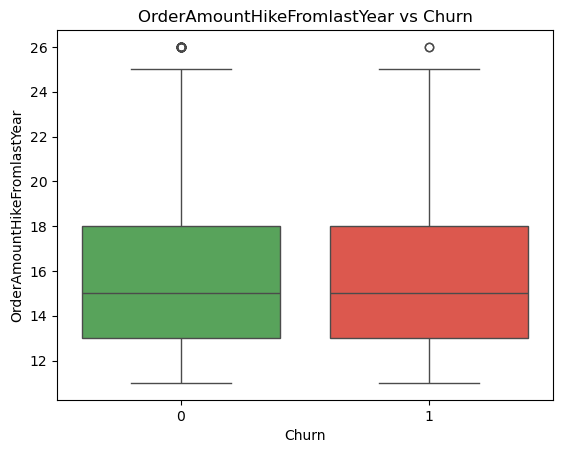

Churn
0    15.0
1    15.0
Name: OrderAmountHikeFromlastYear, dtype: float64

In [29]:
sns.boxplot(x='Churn', y='OrderAmountHikeFromlastYear', data=df, palette=['#4CAF50', '#F44336'])
plt.title("OrderAmountHikeFromlastYear vs Churn")
plt.show()

df.groupby('Churn')['OrderAmountHikeFromlastYear'].median()

In [30]:
ct = pd.crosstab(df['OrderAmountHikeFromlastYear'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 51.01704990848318
p-value: 8.203262504597999e-06


**Explaination:** Terdapat hubungan yang signifikan antara OrderAmountHikeFromlastYear dan Churn

### CouponUsed vs Churn

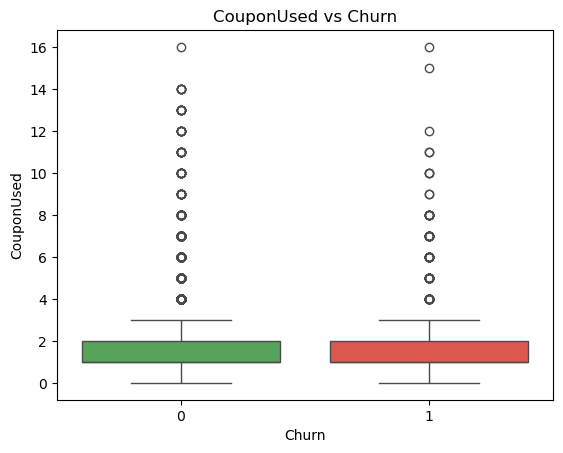

Churn
0    1.0
1    1.0
Name: CouponUsed, dtype: float64

In [31]:
sns.boxplot(x='Churn', y='CouponUsed', data=df, palette=['#4CAF50', '#F44336'])
plt.title("CouponUsed vs Churn")
plt.show()

df.groupby('Churn')['CouponUsed'].median()

In [32]:
ct = pd.crosstab(df['OrderAmountHikeFromlastYear'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 51.01704990848318
p-value: 8.203262504597999e-06


**Explaination:** Tidak terdapat hubungan yang signifikan antara CouponUsed dan Churn

### DaySinceLastOrder vs Churn

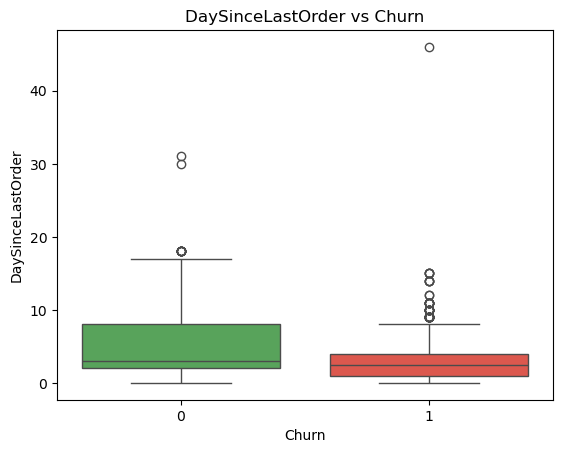

Churn
0    3.0
1    2.5
Name: DaySinceLastOrder, dtype: float64

In [33]:
sns.boxplot(x='Churn', y='DaySinceLastOrder', data=df, palette=['#4CAF50', '#F44336'])
plt.title("DaySinceLastOrder vs Churn")
plt.show()

df.groupby('Churn')['DaySinceLastOrder'].median()

In [34]:
ct = pd.crosstab(df['DaySinceLastOrder'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 262.84410207648074
p-value: 1.0701715583746484e-43


**Explaination:** Terdapat hubungan yang signifikan antara DaySinceLastOrder dan Churn

### CashbackAmount vs Churn


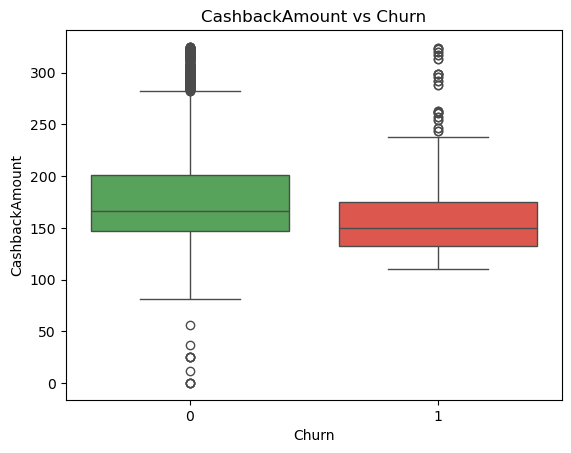

Churn
0    166.115
1    149.660
Name: CashbackAmount, dtype: float64

In [35]:
sns.boxplot(x='Churn', y='CashbackAmount', data=df, palette=['#4CAF50', '#F44336'])
plt.title("CashbackAmount vs Churn")
plt.show()

df.groupby('Churn')['CashbackAmount'].median()

In [36]:
ct = pd.crosstab(df['CashbackAmount'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 4819.258851181046
p-value: 3.90151958052222e-138


**Explaination:** Terdapat hubungan yang signifikan antara CashbackAmount dan Churn

## Bivariate Analysis - Kategorik

### Bivariate Analysis Churn vs. Gender

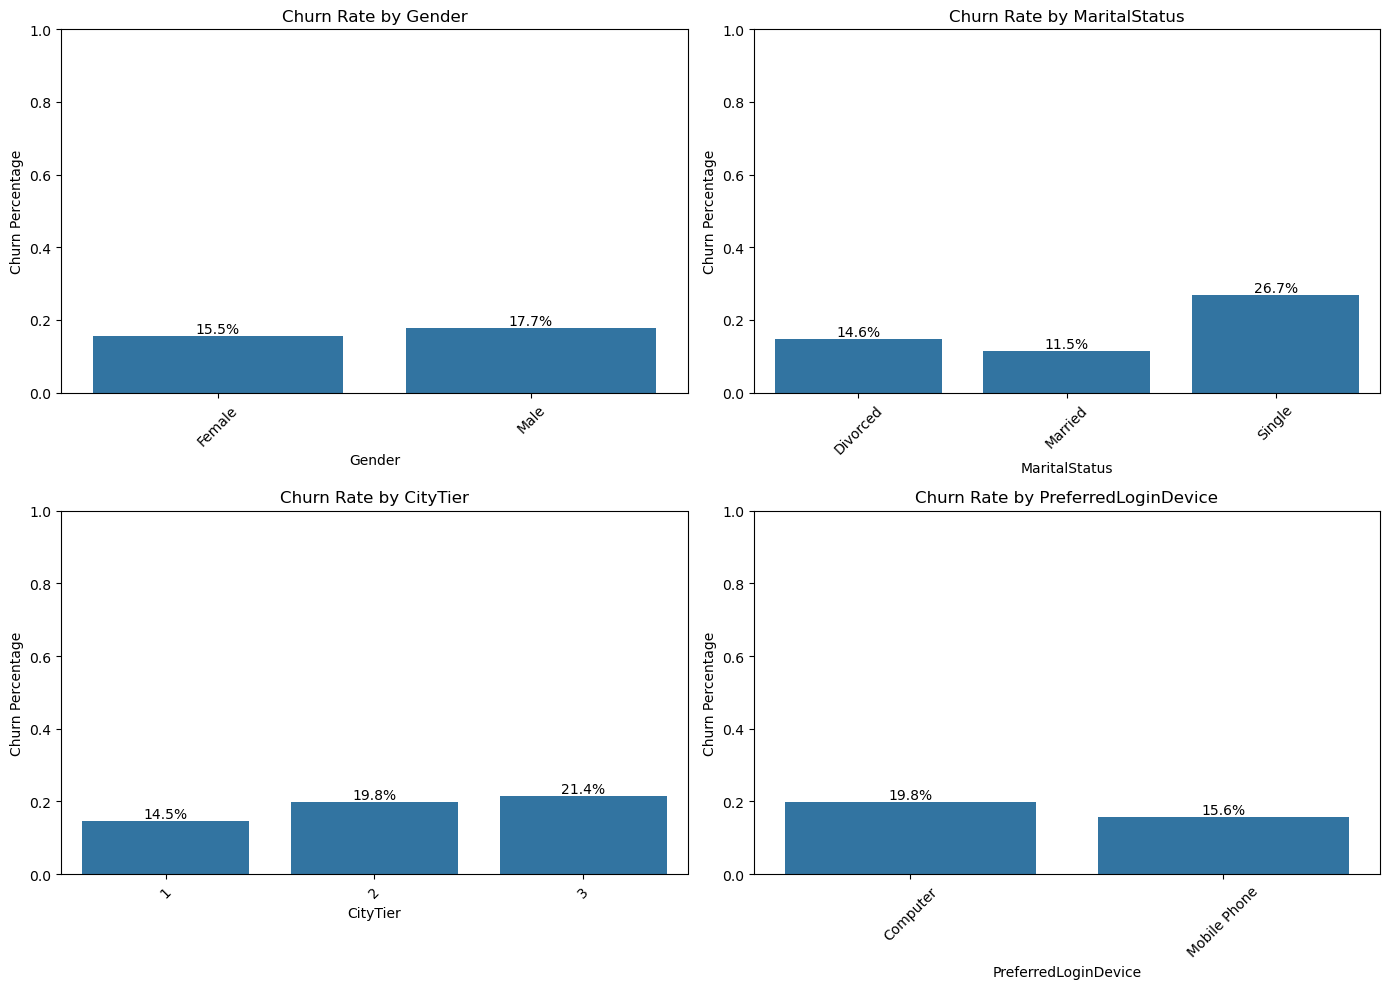

In [37]:
df['Churn'] = df['Churn'].astype(int)

cat_cols = [
    'Gender',
    'MaritalStatus',
    'CityTier',
    'PreferredLoginDevice'
]

# layout subplot
n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # hitung churn rate (PALING AMAN)
    prop_df = (
        df.groupby(col, as_index=False)['Churn']
          .mean()
    )

    sns.barplot(
        data=prop_df,
        x=col,
        y='Churn',
        ax=ax
    )

    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Percentage')
    ax.set_xlabel(col)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

    # label persentase
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height()*100:.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom'
        )

# hapus subplot kosong
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Explanation:** Male cenderung churn, dan juga bertahan. 

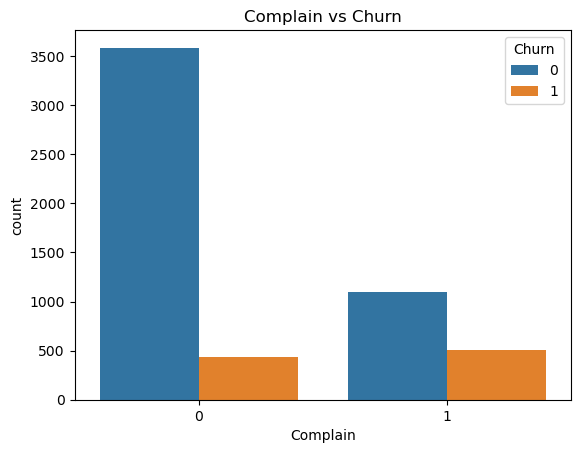

In [38]:
# Bivariate Analysis Complain vs Churn

pd.crosstab(df['Complain'], df['Churn'], normalize='index')
sns.countplot(x='Complain', hue='Churn', data=df)
plt.title("Complain vs Churn")
plt.show()

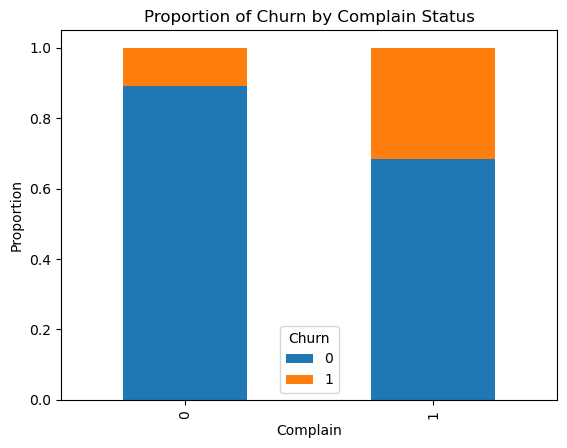

Churn,0,1
Complain,,
0,0.891,0.109
1,0.683,0.317


In [39]:
(ct := pd.crosstab(df['Complain'], df['Churn'], normalize='index')) \
    .plot(kind='bar', stacked=True)

plt.title("Proportion of Churn by Complain Status")
plt.ylabel("Proportion")
plt.show()

pd.crosstab(
    df['Complain'],
    df['Churn'],
    normalize='index'
).round(3)



In [40]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Complain'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)




Chi-square: 350.92545525927073
p-value: 2.664460965464137e-78


**Explanation:** 
1. Pelanggan yang pernah melakukan complain memiliki probabilitas churn jauh lebih tinggi, menjadikan fitur ini salah satu indikator churn terkuat.

2. Terdapat hubungan yang signifikan antara Complain dan Churn

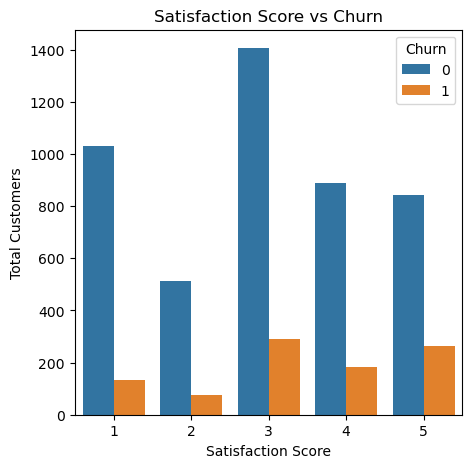

In [41]:
# Bivariate Analysis Satisfaction Score vs Churn

plt.figure(figsize=(5,5))

sns.countplot(
    x='SatisfactionScore',
    hue='Churn',
    data=df
)

plt.title("Satisfaction Score vs Churn")
plt.xlabel("Satisfaction Score")
plt.ylabel("Total Customers")

plt.show()
#######sa

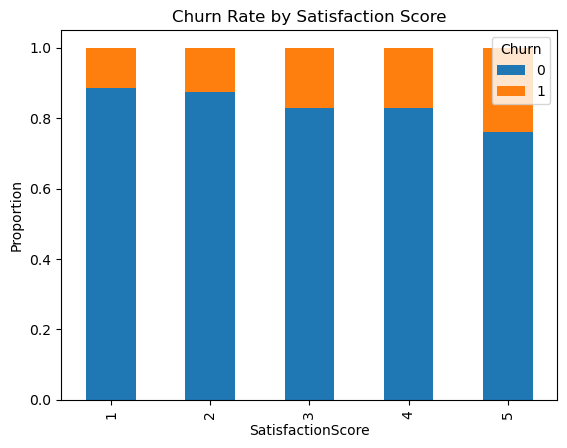

In [42]:
pd.crosstab(
    df['SatisfactionScore'],
    df['Churn'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title("Churn Rate by Satisfaction Score")
plt.ylabel("Proportion")
plt.show()


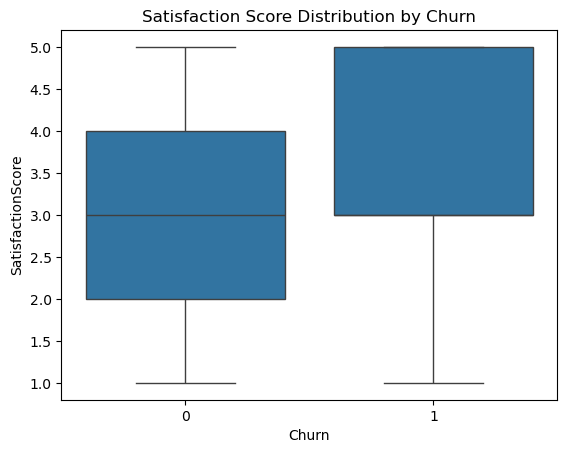

In [43]:
sns.boxplot(
    x='Churn',
    y='SatisfactionScore',
    data=df
)
plt.title("Satisfaction Score Distribution by Churn")
plt.show()


**Explanation:** Rata-rata `SatisfactionScore` adalah 3, terlihat  tidak mempengaruhi faktor utama churn.

**Explanation:** Semakin lama pelanggan tidak melakukan transaksi, semakin tinggi risiko churn. Variabel ini sangat potensial sebagai early warning indicator.

In [44]:
# Heatmap Analysis 

# plt.figure(figsize=(10,6))
# corr = df[num_cols + ['Churn']].corr()
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Correlation Heatmap")
# plt.show()

### Multivariate Analysis

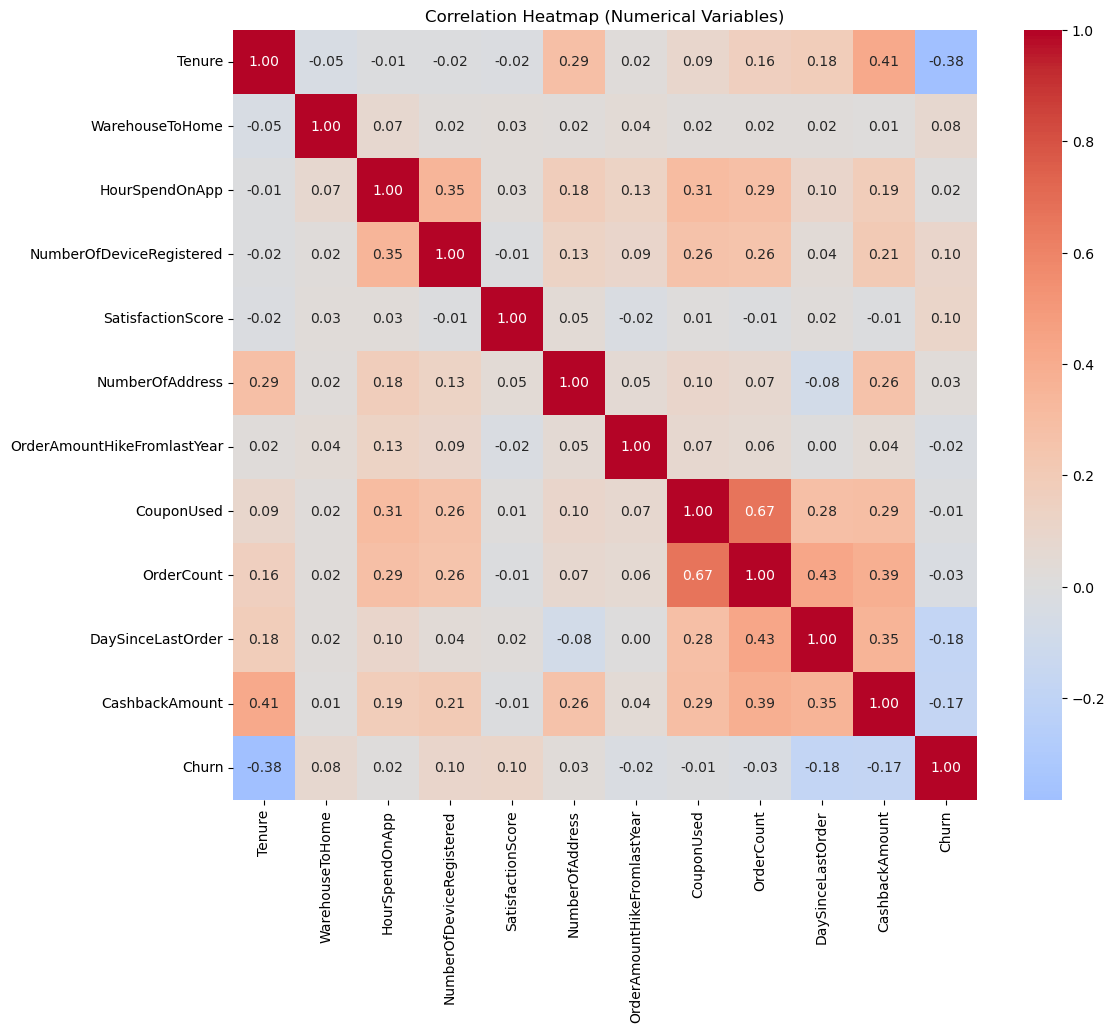

In [45]:
num_cols = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
    'CashbackAmount',
    'Churn'
]

plt.figure(figsize=(12,10))
sns.heatmap(
    df[num_cols].corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap (Numerical Variables)')
plt.show()


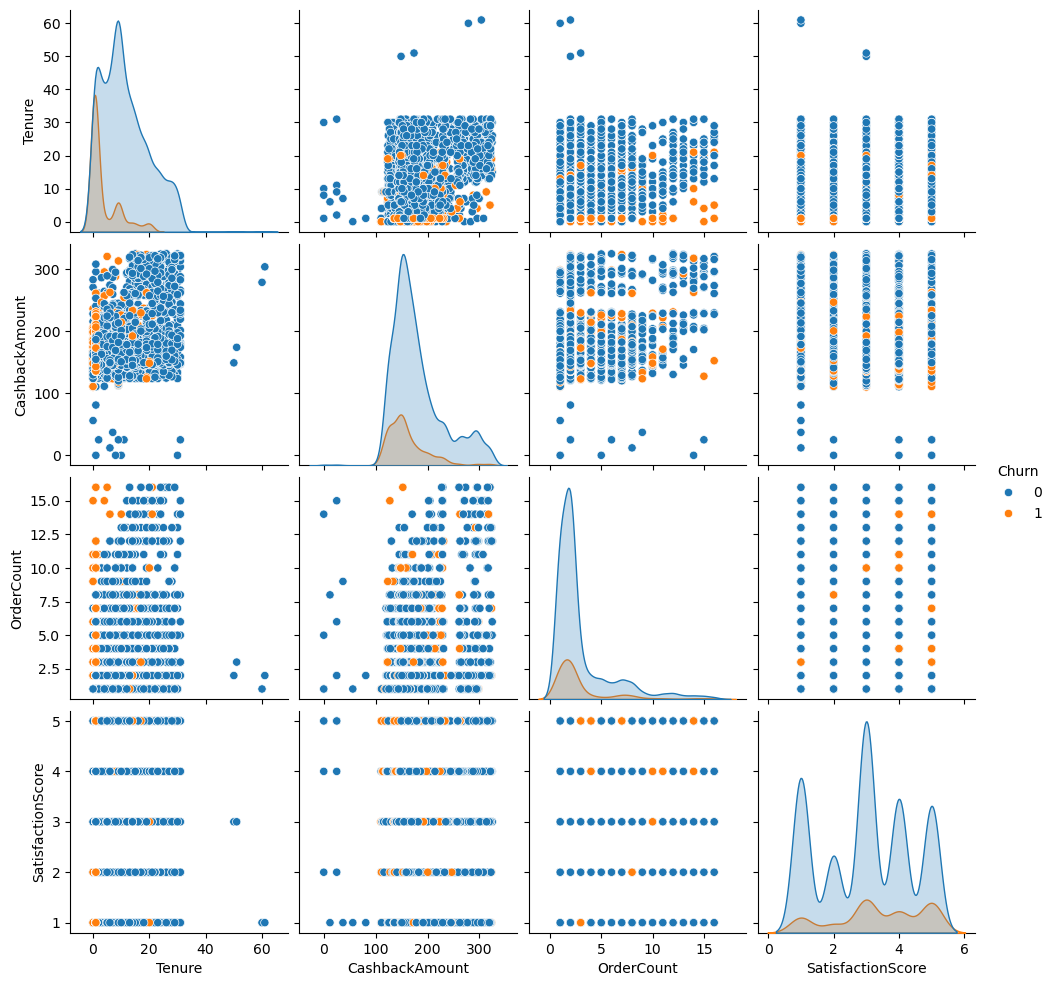

In [46]:
pair_cols = [
    'Tenure',
    'CashbackAmount',
    'OrderCount',
    'SatisfactionScore',
    'Churn'
]

sns.pairplot(
    df[pair_cols],
    hue='Churn',
    diag_kind='kde'
)
plt.show()


**Explanation:**

Hasil analisis korelasi menunjukkan bahwa `Tenure` memiliki hubungan negatif paling kuat dengan **churn (-0.34)**, yang mengindikasikan bahwa semakin lama pelanggan bergabung dengan platform, semakin kecil kemungkinan mereka untuk berhenti bertransaksi. Hal ini menegaskan bahwa pelanggan baru merupakan segmen paling rentan terhadap churn, sehingga perusahaan perlu menerapkan strategi *early retention* sejak fase awal masa langganan.

Variabel `Complain` memiliki korelasi positif **(0.25)** terhadap churn, yang berarti pelanggan yang pernah menyampaikan keluhan memiliki kecenderungan lebih tinggi untuk churn. Temuan ini menekankan pentingnya penanganan keluhan yang cepat dan efektif sebagai bagian dari strategi *service recovery* untuk mencegah kehilangan pelanggan.

Selanjutnya, `DaySinceLastOrder` menunjukkan korelasi negatif lemah hingga menengah **(-0.16)**, yang mengindikasikan bahwa semakin lama pelanggan tidak melakukan pemesanan, risiko churn cenderung meningkat. Variabel ini sangat relevan untuk digunakan sebagai *trigger* dalam kampanye reaktivasi, seperti pengiriman reminder atau penawaran personalisasi.

Sementara itu, `CashbackAmount` memiliki korelasi negatif yang relatif lemah **(-0.15)** terhadap churn. Artinya, meskipun cashback dapat membantu menahan pelanggan, efeknya tidak signifikan jika berdiri sendiri. Hal ini menunjukkan bahwa strategi insentif finansial perlu dikombinasikan dengan peningkatan pengalaman pelanggan agar lebih efektif.

Di luar hubungan langsung dengan churn, terdapat pola menarik pada perilaku pelanggan. Korelasi tinggi antara **CouponUsed** dan **OrderCount** (0.64) menunjukkan bahwa pelanggan yang sering menggunakan kupon juga merupakan pelanggan yang aktif bertransaksi. Selain itu, hubungan antara **OrderCount** dan **DaySinceLastOrder** (0.42) mengonfirmasi bahwa pelanggan dengan frekuensi transaksi tinggi cenderung melakukan pembelian dalam waktu yang lebih dekat.

Terakhir, korelasi positif antara **Tenure** dan **CashbackAmount** (0.47) mengindikasikan bahwa pelanggan lama cenderung menerima cashback lebih besar. Temuan ini perlu dicermati lebih lanjut karena berpotensi menunjukkan praktik *over-subsidizing* terhadap pelanggan yang sebenarnya sudah loyal, sehingga dapat mengurangi efisiensi biaya retensi perusahaan.


In [55]:
# Periksa Ulang Missing Value
df.isnull().sum()

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

## **SPLITTING AND PREPROCCESING DATA**
---

In [115]:
# Split data (train / test)

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (4504, 18) Test: (1126, 18)


## PREPROCCESSING NUMERIC AND CATEGORICAL
---

In [88]:
cat_features_idx = [
    X_train.columns.get_loc(col)
    for col in cat_cols
]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object','category']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)



## PIPELINE AND BASELINE MODEL
---

In [89]:
#pipeline logistic regression
pipeline_lr = Pipeline(steps=[
    ('smote', SMOTENC(
        categorical_features=cat_features_idx,
        sampling_strategy='auto',
        random_state=42
    )),
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])


**Keterangan:**
- Alasan Utama Memilih Logistic Regression sebagai Baseline, karena:
    
    Interpretability Tinggi (Business Trust)
    Koefisien LR:
    - Jelas arah pengaruh (+ / −)
    - mudah diterjemahkan ke bahasa bisnis

- SMOTENC adalah teknik oversampling untuk data imbalanced yang punya fitur numerik DAN kategorikal.

- SMOTENC digunakan jika:
    1. Fokus menekan False Negative
    2. Metrik utama: Recall / F2
    3. Ada business cost besar jika miss positive
    
    Contoh kasus churn:
    
    Lebih baik salah follow-up daripada kehilangan pelanggan

## Hyperparameter Tuning (Optimasi F2 Score)
---

In [90]:


f2_scorer = make_scorer(fbeta_score, beta=2)

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2']
}

grid = GridSearchCV(
    pipeline_lr,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_



## Prediction & F2 Score
---

In [91]:
y_pred = best_model.predict(X_test)

f2 = fbeta_score(y_test, y_pred, beta=2)
print("F2 Score:", round(f2, 4))


F2 Score: 0.6968


**Keterangan:**
- F2 score adalah metrik evaluasi untuk model klasifikasi, turunan dari F-score, yang memberi bobot lebih besar pada Recall dibanding Precision.

- Secara intuitif:
F2 score cocok ketika “kehilangan kasus positif”(**FN**) jauh lebih berbahaya daripada “false alarm”(**FP**).

## Membandingkan Dengan Model Lain
---

In [100]:
#Random Forest
rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus', 'Complain'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, random_state=42))])

In [101]:
#XGBoost

xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')),
                                                 ('cat',
                                                  P...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

**Explanation:**

“Random Forest dan XGBoost dipilih sebagai model pembanding karena keduanya merupakan ensemble tree-based yang kuat namun memiliki mekanisme pembelajaran berbeda. Random Forest berfungsi sebagai benchmark non-linear yang stabil, sementara XGBoost digunakan untuk mengoptimalkan performa pada data churn yang imbalanced dan cost-sensitive.”

In [103]:
# Comparison Table

lr_model = best_model 


def evaluate_model(model, X_test, y_test,
                   ):

    y_pred = model.predict(X_test)

    f2 = fbeta_score(y_test, y_pred, beta=2)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        'F2 Score': round(f2, 4),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
    }



results = pd.DataFrame.from_dict({
    'Logistic Regression': evaluate_model(lr_model, X_test, y_test),
    'Random Forest': evaluate_model(rf_model, X_test, y_test),
    'XGBoost': evaluate_model(xgb_model, X_test, y_test)
}, orient='index')

results


,F2 Score,TP,FP,FN,TN
Logistic Regression,0.6968,154,191,36,745
Random Forest,0.8316,159,37,31,899
XGBoost,0.9604,189,35,1,901


**Temuan:**
Dari membandingkan 3 Model yaitu LogReg, Random forest, dan XGBoost, bahkan telah dilakukan Hyperparemeter Tuning pada LogReg, hasil F2 Score nya menunjukkan model terbaik adalah **_XGBoost_**(F2 Score = 0.9604)

In [106]:
# Hyperparameter Tuning XGBoost

param_grid = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__n_estimators': [200, 300],
    'model__min_child_weight': [1, 5, 10],
    'model__subsample': [0.7, 0.8],
    'model__colsample_bytree': [0.7, 0.8]
}

grid = GridSearchCV(
    xgb_model,
    param_grid,
    scoring=f2_scorer,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model_xgb = grid.best_estimator_

y_pred = best_model_xgb.predict(X_test)

f2 = fbeta_score(y_test, y_pred, beta=2)
print("F2 Score:", round(f2, 4))




F2 Score: 0.9477


## Confusion Matrix
---

Confusion Matrix:
[[905  31]
 [  5 185]]


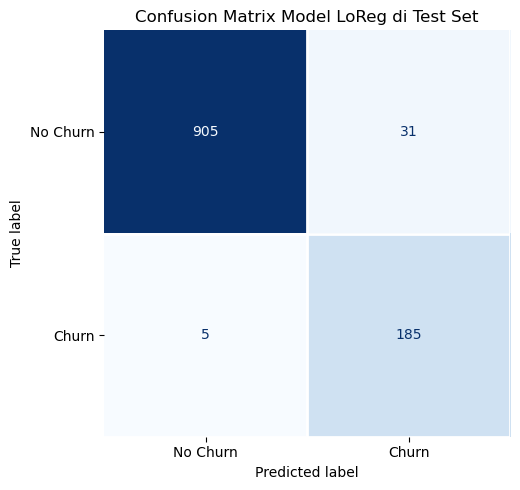

In [107]:

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# Visualisasi dengan grid
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

# Tambahkan grid pemisah antar sel
ax.grid(False)  # matikan grid default
for _, spine in ax.spines.items():
    spine.set_visible(False)

# Tambahkan garis pembatas kotak manual
ax.set_xticks([0, 1], ['No Churn', 'Churn'])
ax.set_yticks([0, 1], ['No Churn', 'Churn'])

# Garis vertikal & horizontal
for x in [0.5, 1.5]:
    ax.axvline(x, color='white', linewidth=2)
for y in [0.5, 1.5]:
    ax.axhline(y, color='white', linewidth=2)

plt.title('Confusion Matrix Model LoReg di Test Set')
plt.tight_layout()
plt.show()


## Profit/Loss & Business Cost Analysis
---

In [ ]:
# Asumsi

COST_FOLLOW_UP = 50_000        # biaya mempertahankan pelanggan
LOSS_CHURN = 2_000_000        # kehilangan 1 pelanggan churn

# Total Cost

total_cost = (
    fp * COST_FOLLOW_UP +   # salah follow-up
    fn * LOSS_CHURN         # churn lolos
)

print("Total Business Cost: Rp{:,.0f}".format(total_cost))

# Cost per Customer

cost_per_customer = total_cost / len(y_test)
print("Cost per Customer: Rp{:,.0f}".format(cost_per_customer))




Total Business Cost: Rp11,550,000
Cost per Customer: Rp10,258


In [114]:
# Membandingkan dengan Tuned Logistic Regression

# Comparison Table

lr_model = best_model 
xgb_best_model = best_model_xgb


def evaluate_model(model, X_test, y_test,
                   cost_follow_up=50_000,
                   loss_churn=2_000_000):

    y_pred = model.predict(X_test)

    f2 = fbeta_score(y_test, y_pred, beta=2)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = (
        fp * cost_follow_up +
        fn * loss_churn
    )

    return {
        'F2 Score': round(f2, 4),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Total Cost (Rp)': total_cost.round(2),
        'Cost per Customer (Rp)': (total_cost / len(y_test)).round(2)
    }

results = pd.DataFrame.from_dict({
    'Logistic Regression': evaluate_model(lr_model, X_test, y_test),
    'XGBoost': evaluate_model(xgb_best_model, X_test, y_test)
}, orient='index')


cost_lr = results.loc['Logistic Regression', 'Total Cost (Rp)']
cost_xgb = results.loc['XGBoost', 'Total Cost (Rp)']

cost_diff_pct = (cost_lr - cost_xgb) / cost_lr * 100
cost_diff_pct = round(cost_diff_pct, 2)

print(f"XGBoost mengurangi total cost sebesar {cost_diff_pct}% dibanding Logistic Regression")

results['Cost Reduction vs LR (%)'] = [
    0,
    round((cost_lr - cost_xgb) / cost_lr * 100, 2)
]

results





XGBoost mengurangi total cost sebesar 85.84% dibanding Logistic Regression


,F2 Score,TP,FP,FN,TN,Total Cost (Rp),Cost per Customer (Rp),Cost Reduction vs LR (%)
Logistic Regression,0.6968,154,191,36,745,81550000,72424.51,0.00
XGBoost,0.9477,185,31,5,905,11550000,10257.55,85.84


**Temuan:**

Dari Comparison Table di atas terlihat bahwa secara Business Cost Analysis dengan menggunakan Model XGBoost yang telah di-tuning, Total Cost nya juah lebih rendah(**Pengurangan sebesar 85,54%**).

## Features Importance
---

In [116]:
def get_feature_names(preprocessor, num_cols, cat_cols):
    num_features = num_cols.tolist()
    
    cat_features = preprocessor.named_transformers_['cat'] \
        .named_steps['onehot'] \
        .get_feature_names_out(cat_cols)
    
    return np.concatenate([num_features, cat_features])

feature_names = get_feature_names(
    preprocessor,
    num_cols,
    cat_cols
)

# Logistic Regression
lr_coef = lr_model.named_steps['model'].coef_[0]

lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coef,
    'Abs_Coefficient': np.abs(lr_coef)
}).sort_values(by='Abs_Coefficient', ascending=False)

lr_importance.head(15)



,Feature,Coefficient,Abs_Coefficient
27,PreferedOrderCat_Others,2.005407,2.005407
25,PreferedOrderCat_Laptop & Accessory,-1.834061,1.834061
0,Tenure,-1.627403,1.627403
30,MaritalStatus_Single,0.954980,0.954980
32,Complain_1,0.886746,0.886746
28,MaritalStatus_Divorced,-0.864161,0.864161
31,Complain_0,-0.792809,0.792809
15,CityTier_3,0.663710,0.663710
19,PreferredPaymentMode_E wallet,0.620243,0.620243
10,CashbackAmount,-0.614294,0.614294


In [117]:
# XGBoost

xgb_model_inner = xgb_best_model.named_steps['model']

xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model_inner.feature_importances_
}).sort_values(by='Importance', ascending=False)

xgb_importance.head(15)


,Feature,Importance
0,Tenure,0.141082
31,Complain_0,0.070494
32,Complain_1,0.046611
15,CityTier_3,0.046569
26,PreferedOrderCat_Mobile Phone,0.044046
25,PreferedOrderCat_Laptop & Accessory,0.036882
23,PreferedOrderCat_Fashion,0.033333
4,SatisfactionScore,0.030284
14,CityTier_2,0.029033
30,MaritalStatus_Single,0.028886


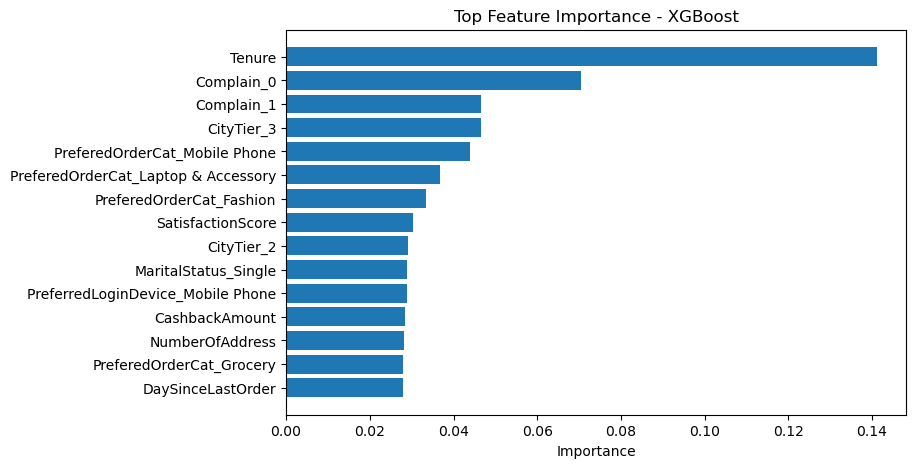

In [118]:
# Visualisasi Features Importance XGBoost

import matplotlib.pyplot as plt

top_n = 15

plt.figure(figsize=(8,5))
plt.barh(
    xgb_importance.head(top_n)['Feature'][::-1],
    xgb_importance.head(top_n)['Importance'][::-1]
)
plt.title("Top Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.show()


**Explanation:**

Fitur yang paling berpengaruh terhadap churn konsisten antara Logistic Regression dan XGBoost, terutama yang berkaitan dengan:
    
    - Pengalaman pelanggan (Satisfaction & Complaint)
    
    - Hubungan jangka panjang (Tenure)
    
    - Insentif & benefit finansial

    - City Tier di mana kota yg lebih kecil biasa nya churn lebih rendah karena pilihan terbatas

### Cost Analysis Perbandingan Dengan ML dan Tanpa ML
---

Total pelanggan evaluasi (test set) : 1.126
Biaya follow-up per pelanggan       : Rp50.000
Kerugian 1 pelanggan churn          : Rp2.000.000

1. Cost Analysis — Tanpa ML
Asumsi:

- Follow-up massal ke 30% pelanggan

- Banyak churn tidak terdeteksi

    Contoh confusion logic (rule-based):
    - FP tinggi
    - FN sangat tinggi

    Perhitungan :
        Follow-up cost      = 338 × 50.000 = Rp16.900.000
        Churn lolos         = 210 × 2.000.000 = Rp420.000.000(18,64% Churn dari data awal)
        Total Cost Tanpa ML = Rp436.900.000

2. Cost Analysis — Dengan ML (XGBoost)

-   False Positive (FP) = 31
    False Negative (FN) = 5

    Perhitungan :
        Follow-up cost      = 31 × 50.000 = Rp1.550.000
        Churn lolos         = 5 × 2.000.000 = Rp10.000.000(18,64% Churn dari data awal)
    T   otal Cost Tanpa ML = Rp11.550.000

3. Keuntungan Menggunakan ML

        Penghematan = Rp436.900.000 - Rp11.550.000
                = Rp425.350.000
        Persentase Penghematan  = (425.350.000/436.900.000)*100%
                                ~> 97%



In [ ]:
import pickle

# Simpan pipeline ke file
with open('ECommerceChurn.pkl', 'wb') as file:
    pickle.dump(best_model, file)
